Tensorflow CNN Source = https://www.tensorflow.org/tutorials/images/cnn

---



#**CNN Model 1**

In [1]:
%pip install tensorflow
import os

# connecting to google drive
from google.colab import drive
drive.mount('/content/drive/')

GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = '1. UVM/Fall 2025/CS 5540/final_project/book_chair_laptop_dataset_352' # change to match your file path
GOOGLE_DRIVE_PATH = os.path.join('drive', 'MyDrive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))

Mounted at /content/drive/
['COCO_train2014_000000321539.json', 'COCO_train2014_000000321539.jpg', 'COCO_train2014_000000452615.json', 'COCO_train2014_000000452615.jpg', 'COCO_train2014_000000241675.json', 'COCO_train2014_000000210956.json', 'COCO_train2014_000000241675.jpg', 'COCO_train2014_000000210956.jpg', 'COCO_train2014_000000040988.json', 'COCO_train2014_000000100386.jpg', 'COCO_train2014_000000100386.json', 'COCO_train2014_000000040988.jpg', 'COCO_train2014_000000372774.jpg', 'COCO_train2014_000000372774.json', 'COCO_train2014_000000327726.jpg', 'COCO_train2014_000000018473.json', 'COCO_train2014_000000018473.jpg', 'COCO_train2014_000000327726.json', 'COCO_train2014_000000049199.jpg', 'COCO_train2014_000000049199.json', 'COCO_train2014_000000321583.json', 'COCO_train2014_000000321583.jpg', 'COCO_train2014_000000507952.jpg', 'COCO_train2014_000000507952.json', 'COCO_train2014_000000176174.json', 'COCO_train2014_000000176174.jpg', 'COCO_train2014_000000319543.jpg', 'COCO_train201

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import json
import numpy as np
from collections import defaultdict
from tensorflow.keras.utils import load_img, img_to_array

base_dir = GOOGLE_DRIVE_PATH

# Used AI (ChatGPT 5) to help format data correclty in order to match data in tensorflow documentation

# create a label map so each class name is tied to a number
# this is what the model will learn to predict later
label_map_all = {'book': 0, 'chair': 1, 'laptop': 2}

# turns the keys (class names) into a set so we can check faster if something is in our target classes
target_classes = set(label_map_all.keys())

# lists that will hold all of our image data and their labels
images, labels = [], []

# function to handle one image at a time
# it finds the dominant object in the image (the one that takes up the most area)
# then loads that image and adds both the image and its label to our lists
def process_one_image(img_path, anns, id2name):
    # keep track of how much area each object class takes up in the image
    area_by_class = defaultdict(float)
    for ann in anns:
        name = id2name.get(ann["category_id"]) # get the class name for this annotation
        if name in target_classes:
            area_by_class[name] += float(ann.get("area", 0.0)) # add its area to that class total

    # skip this image if it doesn't contain any of our target classes
    if not area_by_class:
        return False

    # pick the class with the largest total area (dominant class)
    chosen_name = max(area_by_class.items(), key=lambda kv: kv[1])[0]
    y_raw = label_map_all[chosen_name] # get the label id for that class

    # load and resize the image to 180x180 pixels and scale pixel values between 0 and 1
    img = load_img(img_path, target_size=(180, 180))
    img = img_to_array(img) / 255.0

    # save image and label so we can use them later for training
    images.append(img)
    labels.append(y_raw)
    return True

# loop through everything in our base folder and look for .json files
for fname in os.listdir(base_dir):
    if not fname.endswith(".json"):
        continue # skip anything that isn't a JSON file

    fpath = os.path.join(base_dir, fname)
    with open(fpath, "r") as f:
        data = json.load(f)

    # --- CASE A: combined COCO-style file (one JSON describing all images) ---
    if all(k in data for k in ("images", "annotations", "categories")):
        # link category ids to their names (like 56 -> 'chair')
        id2name = {c["id"]: c["name"] for c in data["categories"]}

        # group all annotations by image_id (so we can process each image easily)
        anns_by_img = defaultdict(list)
        for ann in data["annotations"]:
            anns_by_img[ann["image_id"]].append(ann)

        # now loop through every image described in the JSON
        for img_info in data["images"]:
            img_name = img_info["file_name"]
            img_path = os.path.join(base_dir, img_name)

            # skip if the image doesn't actually exist
            if not os.path.exists(img_path):
                continue

            # process this image and its annotations
            _ = process_one_image(img_path, anns_by_img[img_info["id"]], id2name)

    # --- CASE B: single JSON per image (less common format) ---
    elif "image" in data and "annotations" in data and "categories" in data:
        id2name = {c["id"]: c["name"] for c in data["categories"]}
        img_name = data["image"]["file_name"]
        img_path = os.path.join(base_dir, img_name)
        if not os.path.exists(img_path):
            continue
        _ = process_one_image(img_path, data["annotations"], id2name)

    # --- if it doesn't match either structure, print it and skip ---
    else:
        # Unknown schema: don't crash; tell us which file it was.
        print(f"Skipping {fname} — unexpected keys: {list(data.keys())}")
        continue

# --- after processing all images ---
# convert our image and label lists into numpy arrays (TensorFlow needs this format)
images = np.array(images)
labels = np.array(labels)

# see which class ids we actually ended up with, and how many of each
uniq, counts = np.unique(labels, return_counts=True)
print("Loaded class IDs:", uniq)
print("Counts:", counts)

# remap the labels so they start at 0 and go up to however many classes we actually have
# this helps if some classes are missing from your dataset
present_to_idx = {lab: i for i, lab in enumerate(sorted(uniq))}
labels_mapped = np.array([present_to_idx[lab] for lab in labels], dtype=int)
num_classes = len(present_to_idx)

print("present_to_idx:", present_to_idx)
print("num_classes:", num_classes)
print("mapped uniques:", np.unique(labels_mapped))


Loaded class IDs: [0 1 2]
Counts: [ 56 185 111]
present_to_idx: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2}
num_classes: 3
mapped uniques: [0 1 2]


In [66]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

# 20% for validation, 80% for training
X_train, X_val, y_train, y_val = train_test_split(images, labels_mapped, test_size=0.2, random_state=42, stratify=labels_mapped )

# Create the convolutional base
model = models.Sequential([

    layers.Conv2D(32, (5, 5), activation='relu', padding='same', input_shape=(180, 180, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu',  padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (1, 1), activation='relu',  padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64),
    layers.Dense(num_classes, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)


# Compile and train the model which follows the TensorFlow tutorial documentation
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32
)

loss, accuracy = model.evaluate(X_val, y_val, verbose=2)

print(f"Validation Loss:     {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 353ms/step - accuracy: 0.4876 - loss: 1.0381 - val_accuracy: 0.5211 - val_loss: 1.0248
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5128 - loss: 1.0044 - val_accuracy: 0.5211 - val_loss: 1.0052
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5034 - loss: 1.0135 - val_accuracy: 0.5211 - val_loss: 1.0027
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5183 - loss: 0.9847 - val_accuracy: 0.5211 - val_loss: 1.0004
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5245 - loss: 0.9577 - val_accuracy: 0.5211 - val_loss: 0.9964
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5371 - loss: 0.9475 - val_accuracy: 0.5211 - val_loss: 0.9956
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5284 - loss: 0.9532 - val_accuracy: 0.5352 - val_loss: 0.9924
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5408 - loss: 0.9303 - val_accuracy: 0.5352 - val_loss: 0.9920
Epoch 9/15

In [67]:
# complete architecture of your model:
model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 180, 180, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 45, 45, 128)    │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │     3,964,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,983,307 (45.71 MB)

 Trainable params: 3,994,435 (15.24 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,988,872 (30.48 MB)

In [68]:
# Invert raw id -> name using your global label map
raw_id_to_name = {v: k for k, v in label_map_all.items()}

# Build names aligned to mapped indices 0..K-1
class_names = [raw_id_to_name[raw_id] for raw_id in sorted(uniq)]  # same order used in mapping
print("class_names (by mapped id):", class_names)

class_names (by mapped id): ['book', 'chair', 'laptop']


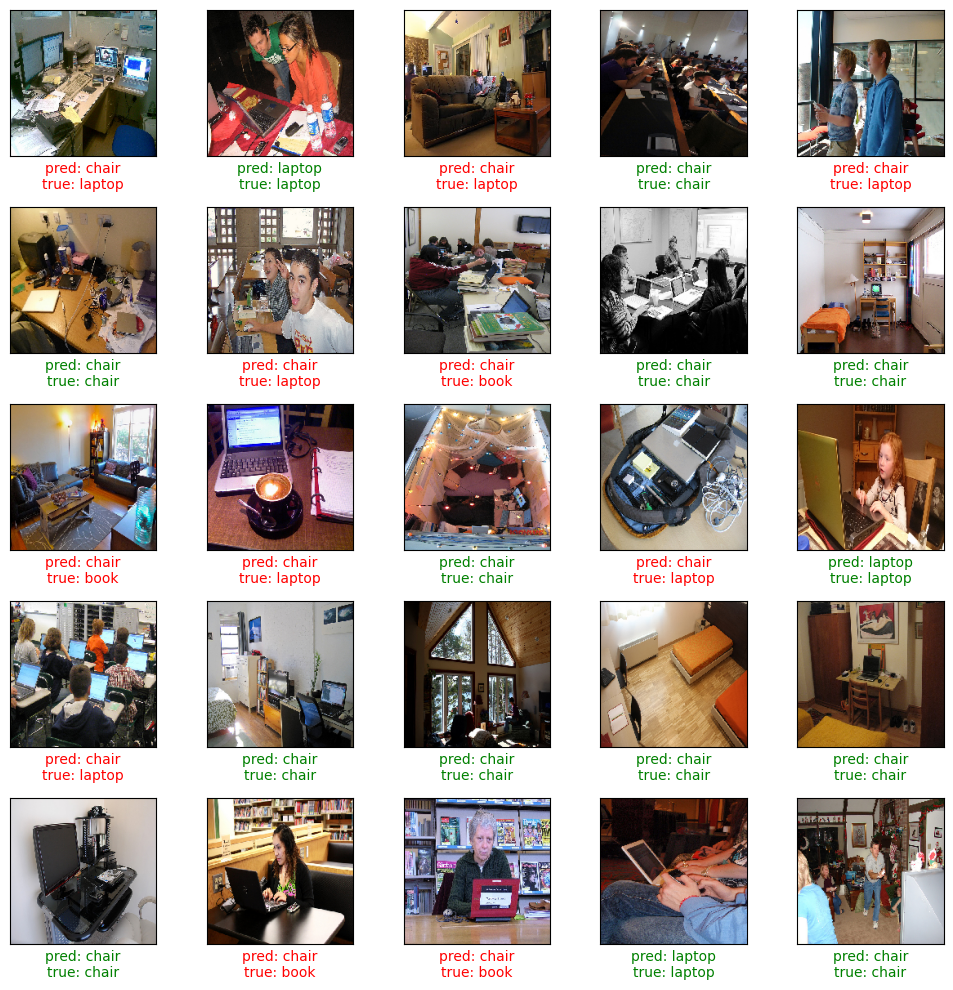

In [69]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
logits = model.predict(X_val[:25], verbose=0)
preds  = tf.nn.softmax(logits, axis=-1).numpy().argmax(axis=1)

plt.figure(figsize=(10, 10))
for i in range(len(preds)):
    plt.subplot(5, 5, i + 1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(X_val[i])
    true_name = class_names[int(y_val[i])]
    pred_name = class_names[int(preds[i])]
    color = "green" if pred_name == true_name else "red"
    plt.xlabel(f"pred: {pred_name}\ntrue: {true_name}", color=color)
plt.tight_layout()
plt.show()


3/3 - 0s - 35ms/step - accuracy: 0.5634 - loss: 0.9853
Test Accuracy: 0.5633803009986877


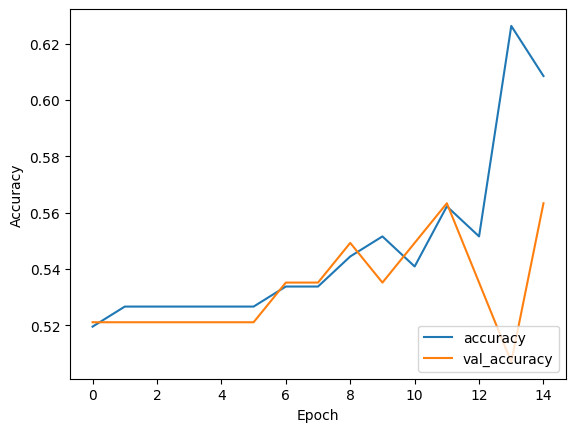

In [70]:
# Evaluate the model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_val,  y_val, verbose=2)

print(f'Test Accuracy: {test_acc}')

#**Transfer learning and fine-tuning model 1**

In [71]:

# splitting data using same split from above
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .shuffle(len(X_train))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


print('Number of validation batches: %d' % tf.data.experimental.cardinality(val_ds))
print('Number of train batches: %d' % tf.data.experimental.cardinality(train_ds))

Number of validation batches: 3
Number of train batches: 9


In [72]:
# Use data augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

# Rescale pixel values
# This model expects pixel values in [-1, 1], but at this point, the pixel values in your images are in [0, 255].
# To rescale them, use the preprocessing method included with the model.
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input


In [73]:
# Create the base model from the pre-trained model MobileNet V2
IMG_SIZE = (180, 180)
IMG_SHAPE = IMG_SIZE + (3,)

# Pretrained base
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
image_batch, label_batch = next(iter(train_ds))
image_batch_proc = preprocess_input(image_batch)
feature_batch = base_model(image_batch_proc)
print(feature_batch.shape)

/tmp/ipython-input-3357994476.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


(32, 6, 6, 1280)


In [74]:
# Freeze the convolutional base (prevents the weights in a given layer from being updated during training)
base_model.trainable = False

# Add a classification head
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print("classification head", feature_batch_average.shape)

# Apply a tf.keras.layers.Dense layer to convert these features into a single prediction per image
prediction_layer = tf.keras.layers.Dense(num_classes)
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)



classification head (32, 1280)
(32, 3)


In [75]:
# Build a model by chaining together the data augmentation, rescaling, base_model and feature extractor layers using the Keras Functional API.
# As previously mentioned, use training=False as our model contains a BatchNormalization layer.
inputs = tf.keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = x * 255.0
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_25 (Sequential)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_1 (Multiply)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [76]:
# compile model
base_learning_rate = 1e-4
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# train model
initial_epochs = 15
loss0, accuracy0 = model.evaluate(val_ds)

history = model.fit(train_ds,
                    epochs=initial_epochs,
                    validation_data=val_ds)

loss_value, accuracy_value = model.evaluate(val_ds)

print(f"Validation Loss:     {loss_value:.4f}")
print(f"Validation Accuracy: {accuracy_value:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.1814 - loss: 1.8092
Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.2473 - loss: 1.7471 - val_accuracy: 0.2817 - val_loss: 1.5164
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3968 - loss: 1.4009 - val_accuracy: 0.3380 - val_loss: 1.3557
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4320 - loss: 1.2713 - val_accuracy: 0.3662 - val_loss: 1.3072
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4582 - loss: 1.3033 - val_accuracy: 0.3662 - val_loss: 1.2854
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4378 - loss: 1.3364 - val_accuracy: 0.3662 - val_loss: 1.2692
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4540 - loss: 1.2856 - val_accuracy: 0.3662 - val_loss: 1.2567
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4428 - loss: 1.2770 - val_accuracy: 0.3662 - val_loss: 1.2445
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - ac

Text(0.5, 1.0, 'Training and Validation Accuracy')

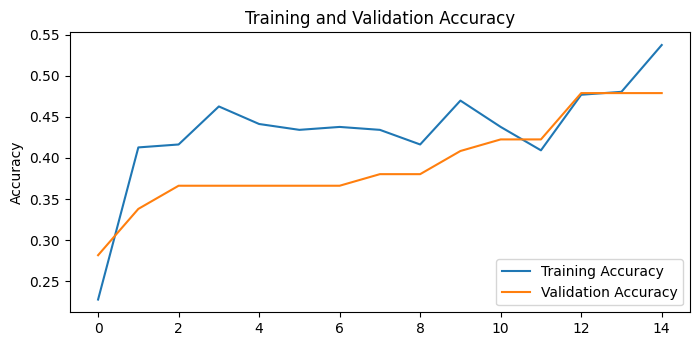

In [77]:
# plotting learning curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

## Fine-Tuning Tranfer Learning Model

In [78]:
base_model.trainable = True

# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


In [79]:
fine_tune_lr = base_learning_rate / 10

model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=fine_tune_lr),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model.summary()

Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_25 (Sequential)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_1 (Multiply)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 1,865,283 (7.12 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [80]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_ds,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=val_ds)

loss_value, accuracy_value = model.evaluate(val_ds)

print(f"Validation Loss:     {loss_value:.4f}")
print(f"Validation Accuracy: {accuracy_value:.4f}")

Epoch 16/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 250ms/step - accuracy: 0.4046 - loss: 1.1379 - val_accuracy: 0.4930 - val_loss: 1.1141
Epoch 17/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.4765 - loss: 1.1068 - val_accuracy: 0.5070 - val_loss: 1.1035
Epoch 18/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.4814 - loss: 1.0263 - val_accuracy: 0.4789 - val_loss: 1.1030
Epoch 19/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.5059 - loss: 1.0084 - val_accuracy: 0.4789 - val_loss: 1.0989
Epoch 20/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.4978 - loss: 0.9822 - val_accuracy: 0.4930 - val_loss: 1.0966
Epoch 21/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.5091 - loss: 1.0365 - val_accuracy: 0.5070 - val_loss: 1.0962
Epoch 22/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6053 - loss: 0.9193 - val_accuracy: 0.5211 - val_loss: 1.0907
Epoch 23/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.5872 - loss: 0.9636 - val_accuracy: 0.5352 - val_los

Text(0.5, 1.0, 'Training and Validation Accuracy')

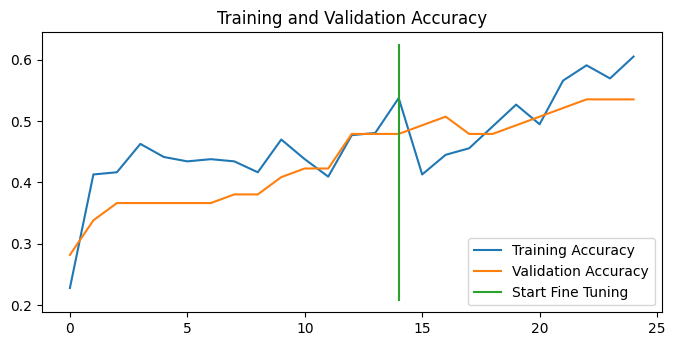

In [81]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')